# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Plan for this section:**

Self-contained, per the w06 convention — reload the raw CSV and rebuild
everything needed rather than depending on notebook state from w04/w05/w06.

**Two components feed the final ranked queue:**

1. **The RF model (validated in w05, audited clean in w06).**
   Client-grouped split, same 38 features, same hyperparameters
   (`n_estimators=300, max_depth=8, min_samples_leaf=20, seed=42`).
   Precision@K=1523 was 0.648 vs. base rate 0.511 on held-out clients —
   that's the number earning this model a place in a real queue.

   **Design decision, stated plainly:** the w05/w06 split held out 7
   clients to prove the model generalizes to clients it never trained on.
   That proof is done. For the deployable queue, I refit RF on the *full*
   30,000-row dataset (all 32 clients) with the identical feature set and
   hyperparameters — every client gets a score, and nothing here reuses
   the held-out test set to inflate a number, since no metric is being
   reported from this refit. The precision@K=0.648 claim still belongs to
   the w05/w06 split, not to this refit.

2. **The baseline rule (`score_row()` from w04), recomputed exactly** —
   its two reason codes (`CTR_GAP_MIDPOS`, `LOW_VOLUME`) are more
   interpretable than an RF probability and become the human-readable
   part of the reason code, even when RF is what's actually driving the
   ranking.

**Archetype → action mapping**, computed per row from RF top-K status,
baseline reason code, and the three known weak-spot flags from w06:

| Archetype | Condition | Action | Confidence |
|---|---|---|---|
| CTR gap, mid-position | `reason_code == CTR_GAP_MIDPOS` | Rewrite title/meta | High — audited signal |
| Low-demand page | `reason_code == LOW_VOLUME` only | Deprioritize/consolidate | Medium — direction confirmed, weak effect |
| RF-flagged, no baseline signal | Top-K by `rf_proba`, `reason_code == NO_SIGNAL` | Review before acting | Medium — real but less legible signal |
| Missing `provider_used` | Top-K, `provider_used` is null | Low-confidence flag | Low — worst FN segment (80.9%) |
| `client_8527a891e2` | Any flag, this client | Downweight | Low — known elevated FP client (0.600) |
| `avg_position == 0` | Any flag, position=0 | Hold for manual check | Low — "no data" fed as literal 0 |

Ranking itself is `rf_proba` descending (the validated better metric); the
reason code and confidence tag are what make each row legible and
appropriately trusted — a `priority_fix` from a clean archetype and a
`priority_fix` from client_8527a891e2 should not read the same to a human
reviewer.

**Output of this section:** a full-dataset queue with `content_id`,
`rf_proba`, rank, baseline `reason_code`, `archetype`, `action`,
`confidence`. Distribution checks (archetype counts, action counts)
printed as a sanity pass before Section 2 defines intended use around it.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)
print(f"rows: {len(df):,}  cols: {df.shape[1]}")

rows: 30,000  cols: 44


In [3]:
# --- Baseline rule (w04, unchanged) ---
def score_row(row):
    score = 0
    reasons = []
    sv = row.get("search_volume", np.nan)
    if pd.notna(sv):
        if sv <= 10:
            score += 2
            reasons.append(("LOW_VOLUME", 2))
        elif sv <= 20:
            score += 1
            reasons.append(("LOW_VOLUME", 1))
    pos = row.get("avg_position", np.nan)
    ctr = row.get("ctr", np.nan)
    if pd.notna(pos) and pd.notna(ctr) and 7.4 < pos <= 17.2:
        if ctr <= 0.23:
            score += 3
            reasons.append(("CTR_GAP_MIDPOS", 3))
    reason_code = max(reasons, key=lambda r: r[1])[0] if reasons else "NO_SIGNAL"
    if score >= 3:
        baseline_action = "priority_fix"
    elif score >= 1:
        baseline_action = "monitor"
    else:
        baseline_action = "no_action"
    return pd.Series({"score": score, "reason_code": reason_code, "baseline_action": baseline_action})

In [4]:
baseline_scored = df.apply(score_row, axis=1)
df = pd.concat([df, baseline_scored], axis=1)
K = (df["baseline_action"] == "priority_fix").sum()
print(f"Baseline flags {K:,} rows as priority_fix on the full dataset (K)")

Baseline flags 6,690 rows as priority_fix on the full dataset (K)


In [5]:
# --- RF model: same 38-feature set + hyperparameters as w05/w06, refit on the FULL dataset ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [6]:
SEED = 42
candidate_features = [c for c in df.columns if c not in
                      ["trend_direction", "trend_pct", "client_id", "content_id",
                       "score", "reason_code", "baseline_action"]]
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]
print(f"Using {len(FEATURE_COLS)} features (should match w05/w06's 38)")

Using 38 features (should match w05/w06's 38)


In [7]:
categorical_cols = df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

In [8]:
def build_feature_frame(frame):
    out = frame[FEATURE_COLS].copy()
    for col in numeric_cols:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_cols:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [9]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [10]:
y_full = (df["trend_direction"] == "down").astype(int)
X_full = build_feature_frame(df)

In [11]:
rf_deploy = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                    random_state=SEED, n_jobs=-1)),
])
rf_deploy.fit(X_full, y_full)
df["rf_proba"] = rf_deploy.predict_proba(X_full)[:, 1]

print("NOTE: refit on all 32 clients for full deploy coverage. The 0.648 precision@K claim "
      "belongs to the w05/w06 held-out-client evaluation, not to this refit — no metric is "
      "being reported from this fit itself.")

NOTE: refit on all 32 clients for full deploy coverage. The 0.648 precision@K claim belongs to the w05/w06 held-out-client evaluation, not to this refit — no metric is being reported from this fit itself.


In [12]:
# --- Rank + archetype / action / confidence assignment ---
# Precedence, deliberately: weak-spot conditions (client, missing position data,
# missing provider) are checked BEFORE the clean baseline archetypes, because they're
# about how much to trust the row at all, not a competing reason for the flag.
df_ranked = df.sort_values("rf_proba", ascending=False).reset_index(drop=True)
df_ranked["rank"] = df_ranked.index + 1
df_ranked["in_top_k"] = df_ranked["rank"] <= K

WEAK_CLIENT = "client_8527a891e2"

In [13]:
def assign_archetype(row):
    if row["in_top_k"] and row["client_id"] == WEAK_CLIENT:
        return "weak_client_flag", "downweight_verify_manually", "low"
    if row["in_top_k"] and row["avg_position"] == 0:
        return "no_position_data", "hold_for_manual_check", "low"
    if row["in_top_k"] and pd.isna(row["provider_used"]):
        return "missing_provider_flag", "low_confidence_flag", "low"
    if row["reason_code"] == "CTR_GAP_MIDPOS":
        return "ctr_gap_midposition", "rewrite_title_meta", "high"
    if row["reason_code"] == "LOW_VOLUME":
        return "low_demand_page", "deprioritize_consolidate", "medium"
    if row["in_top_k"]:
        return "rf_flagged_no_baseline_signal", "review_before_acting", "medium"
    return "no_flag", "no_action", "n/a"

In [14]:
archetype_results = df_ranked.apply(assign_archetype, axis=1, result_type="expand")
archetype_results.columns = ["archetype", "action", "confidence"]
df_ranked = pd.concat([df_ranked, archetype_results], axis=1)

In [15]:
queue = df_ranked[["content_id", "rank", "rf_proba", "reason_code", "archetype", "action", "confidence"]]

In [16]:
print("Archetype distribution:")
print(queue["archetype"].value_counts())
print("\nAction distribution:")
print(queue["action"].value_counts())
print("\nConfidence distribution:")
print(queue["confidence"].value_counts())

queue.head(20)

Archetype distribution:
archetype
low_demand_page                  13690
no_flag                           6560
ctr_gap_midposition               5717
missing_provider_flag             3553
rf_flagged_no_baseline_signal      432
weak_client_flag                    48
Name: count, dtype: int64

Action distribution:
action
deprioritize_consolidate      13690
no_action                      6560
rewrite_title_meta             5717
low_confidence_flag            3553
review_before_acting            432
downweight_verify_manually       48
Name: count, dtype: int64

Confidence distribution:
confidence
medium    14122
n/a        6560
high       5717
low        3601
Name: count, dtype: int64


,content_id,rank,rf_proba,reason_code,archetype,action,confidence
0,content_20e4b9f7f65e,1,0.871360,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
1,content_5f2abb891cc6,2,0.870377,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
2,content_ab82c4705992,3,0.869578,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
3,content_673fe764797f,4,0.866374,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
4,content_0a08fba69bf3,5,0.863840,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
5,content_252c884e4400,6,0.861644,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
6,content_4bcb30ab7531,7,0.861544,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
7,content_875fc7912e9b,8,0.860653,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
8,content_007238e62b42,9,0.855492,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
9,content_95c47359824d,10,0.853420,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low


In [17]:
# --- Verify #3: is no_position_data really zero, or did the precedence order hide it? ---
zero_pos_total = (df["avg_position"] == 0).sum()
zero_pos_in_topk = df_ranked.loc[df_ranked["in_top_k"], "avg_position"].eq(0).sum()

print(f"avg_position == 0 rows in full dataset: {zero_pos_total:,} ({zero_pos_total/len(df):.1%})")
print(f"avg_position == 0 rows within top-K (flagged): {zero_pos_in_topk:,}")

avg_position == 0 rows in full dataset: 1,205 (4.0%)
avg_position == 0 rows within top-K (flagged): 0


In [18]:
# Where do these rows actually rank, and what does their rf_proba look like?
zero_pos_rows = df_ranked[df_ranked["avg_position"] == 0]
print(f"Rank distribution of avg_position==0 rows (min/median/max rank of {len(zero_pos_rows):,} rows):")
print(zero_pos_rows["rank"].agg(["min", "median", "max"]))
print(f"\nrf_proba distribution of avg_position==0 rows vs. the rest:")
print(f"  avg_position==0:  mean rf_proba = {zero_pos_rows['rf_proba'].mean():.4f}")
print(f"  avg_position!=0:  mean rf_proba = {df_ranked.loc[df_ranked['avg_position']!=0, 'rf_proba'].mean():.4f}")

Rank distribution of avg_position==0 rows (min/median/max rank of 1,205 rows):
min       23174.0
median    29398.0
max       30000.0
Name: rank, dtype: float64

rf_proba distribution of avg_position==0 rows vs. the rest:
  avg_position==0:  mean rf_proba = 0.0339
  avg_position!=0:  mean rf_proba = 0.5631


In [19]:
# --- Coverage completeness check: does every row have exactly one archetype, and do
# the archetype/action/confidence columns stay internally consistent? ---
print(f"Total rows: {len(queue):,}  |  Rows with an archetype assigned: {queue['archetype'].notna().sum():,}")

# Cross-tab: does archetype line up with in_top_k as expected (all flagged archetypes
# should be in_top_k=True, no_flag should be in_top_k=False)?
consistency = df_ranked.groupby("archetype")["in_top_k"].agg(["min", "max", "size"])
print("\narchetype vs in_top_k (min/max should match within each archetype — no mixed group):")
print(consistency)

# Cross-tab: reason_code vs archetype, to make the precedence logic legible in one table
print("\nreason_code x archetype crosstab (shows exactly how baseline reason codes route into archetypes):")
print(pd.crosstab(df_ranked["reason_code"], df_ranked["archetype"]))

Total rows: 30,000  |  Rows with an archetype assigned: 30,000

archetype vs in_top_k (min/max should match within each archetype — no mixed group):
                                 min    max   size
archetype                                         
ctr_gap_midposition            False   True   5717
low_demand_page                False   True  13690
missing_provider_flag           True   True   3553
no_flag                        False  False   6560
rf_flagged_no_baseline_signal   True   True    432
weak_client_flag                True   True     48

reason_code x archetype crosstab (shows exactly how baseline reason codes route into archetypes):
archetype       ctr_gap_midposition  low_demand_page  missing_provider_flag  no_flag  rf_flagged_no_baseline_signal  weak_client_flag
reason_code                                                                                                                          
CTR_GAP_MIDPOS                 5717                0                    954 

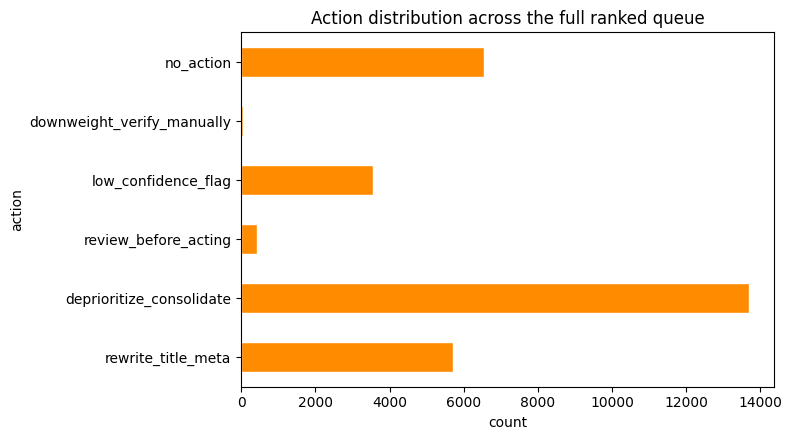

In [20]:
# --- Visualizations ---
import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

# Viz 1: action distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
action_order = ["rewrite_title_meta", "deprioritize_consolidate", "review_before_acting",
                 "low_confidence_flag", "downweight_verify_manually", "no_action"]
queue["action"].value_counts().reindex(action_order).plot(
    kind="barh", ax=ax, color="darkorange", edgecolor="white"
)
ax.set_xlabel("count")
ax.set_title("Action distribution across the full ranked queue")
plt.tight_layout()
plt.savefig("work/outputs/w07_action_distribution.png", dpi=150)
plt.show()

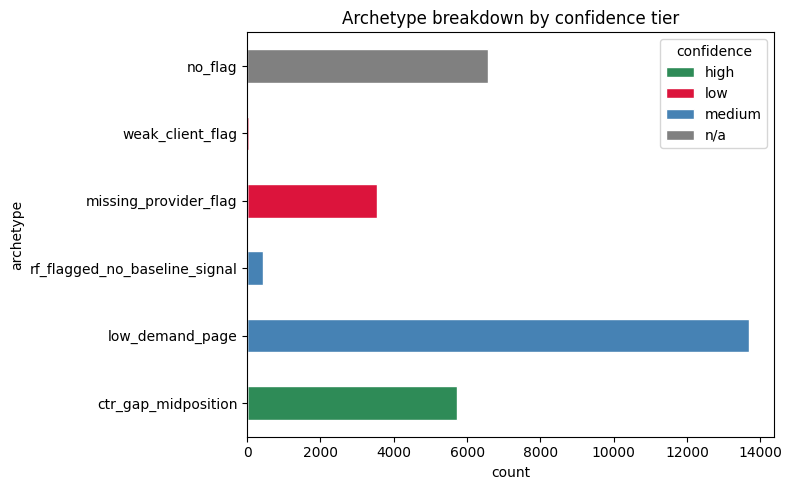

In [21]:
# Viz 2: archetype x confidence, stacked
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df_ranked["archetype"], df_ranked["confidence"])
ct = ct.reindex(["ctr_gap_midposition", "low_demand_page", "rf_flagged_no_baseline_signal",
                  "missing_provider_flag", "weak_client_flag", "no_flag"])
ct.plot(kind="barh", stacked=True, ax=ax, edgecolor="white",
        color={"high": "seagreen", "medium": "steelblue", "low": "crimson", "n/a": "gray"})
ax.set_xlabel("count")
ax.set_title("Archetype breakdown by confidence tier")
ax.legend(title="confidence")
plt.tight_layout()
plt.savefig("work/outputs/w07_archetype_by_confidence.png", dpi=150)
plt.show()

/tmp/ipykernel_1155/2290585386.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=archetype_order_topk, patch_artist=True)


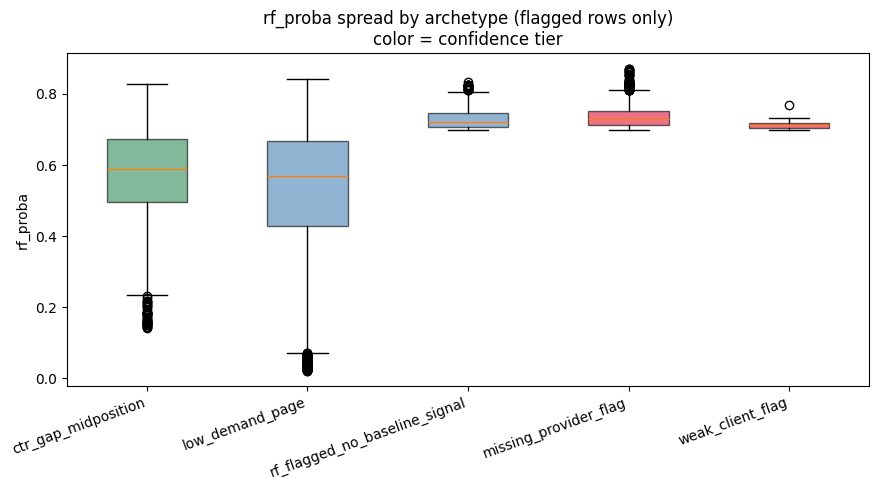

In [22]:
# Viz 3: rf_proba distribution by archetype — does confidence correspond to where
# rf_proba actually sits, or is a "low confidence" row scoring just as high as a "high"?
fig, ax = plt.subplots(figsize=(9, 5))
archetype_order_topk = ["ctr_gap_midposition", "low_demand_page", "rf_flagged_no_baseline_signal",
                         "missing_provider_flag", "weak_client_flag"]
data_to_plot = [df_ranked.loc[df_ranked["archetype"] == a, "rf_proba"].values for a in archetype_order_topk]
bp = ax.boxplot(data_to_plot, labels=archetype_order_topk, patch_artist=True)
for patch, color in zip(bp["boxes"], ["seagreen", "steelblue", "steelblue", "crimson", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("rf_proba")
ax.set_title("rf_proba spread by archetype (flagged rows only)\ncolor = confidence tier")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/outputs/w07_rfproba_by_archetype.png", dpi=150)
plt.show()


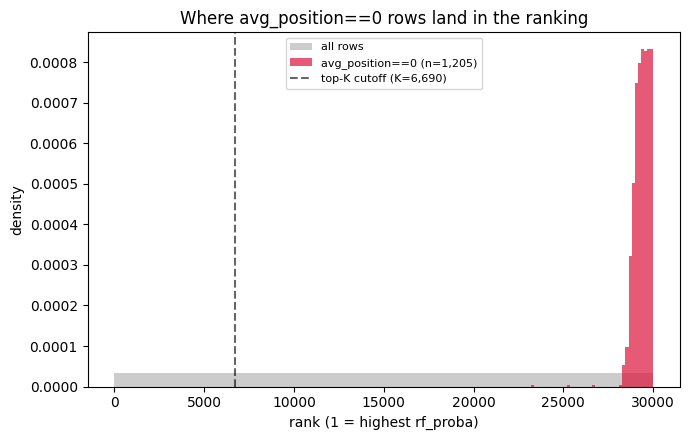

In [23]:
# Viz 4: avg_position==0 rows — where do they actually rank? (supports the verification cell above)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df_ranked["rank"], bins=40, alpha=0.4, label="all rows", color="gray", density=True)
ax.hist(zero_pos_rows["rank"], bins=40, alpha=0.7, label=f"avg_position==0 (n={len(zero_pos_rows):,})",
        color="crimson", density=True)
ax.axvline(K, linestyle="--", color="black", alpha=0.6, label=f"top-K cutoff (K={K:,})")
ax.set_xlabel("rank (1 = highest rf_proba)")
ax.set_ylabel("density")
ax.set_title("Where avg_position==0 rows land in the ranking")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w07_zero_position_rank_dist.png", dpi=150)
plt.show()

In [24]:
# --- Quantify the in_top_k mismatch inside ctr_gap_midposition / low_demand_page ---
for arch in ["ctr_gap_midposition", "low_demand_page"]:
    sub = df_ranked[df_ranked["archetype"] == arch]
    in_k = sub["in_top_k"].sum()
    out_k = (~sub["in_top_k"]).sum()
    print(f"[{arch}] total={len(sub):,}  in_top_k={in_k:,} ({in_k/len(sub):.1%})  "
          f"outside_top_k={out_k:,} ({out_k/len(sub):.1%})")
    print(f"  rank of outside-top_k rows: median={sub.loc[~sub['in_top_k'], 'rank'].median():.0f}, "
          f"max={sub.loc[~sub['in_top_k'], 'rank'].max():.0f}")

[ctr_gap_midposition] total=5,717  in_top_k=894 (15.6%)  outside_top_k=4,823 (84.4%)
  rank of outside-top_k rows: median=16209, max=28653
[low_demand_page] total=13,690  in_top_k=1,763 (12.9%)  outside_top_k=11,927 (87.1%)
  rank of outside-top_k rows: median=17489, max=29458


In [25]:
# --- Add queue_tier: makes the rank-vs-reason_code distinction explicit in the data itself ---
def assign_queue_tier(row):
    if row["in_top_k"]:
        return "top_priority"
    elif row["reason_code"] != "NO_SIGNAL":
        return "flagged_lower_rank"
    else:
        return "unflagged"

In [26]:
df_ranked["queue_tier"] = df_ranked.apply(assign_queue_tier, axis=1)

In [27]:
# Rebuild the final queue export with the new column included
queue = df_ranked[["content_id", "rank", "rf_proba", "reason_code",
                    "archetype", "action", "confidence", "queue_tier"]]

In [28]:
print("queue_tier distribution:")
print(queue["queue_tier"].value_counts())

print("\nqueue_tier x archetype crosstab (confirms the split cleanly, no leftover mixing):")
print(pd.crosstab(df_ranked["queue_tier"], df_ranked["archetype"]))

print("\nqueue_tier x confidence crosstab:")
print(pd.crosstab(df_ranked["queue_tier"], df_ranked["confidence"]))

queue_tier distribution:
queue_tier
flagged_lower_rank    16750
top_priority           6690
unflagged              6560
Name: count, dtype: int64

queue_tier x archetype crosstab (confirms the split cleanly, no leftover mixing):
archetype           ctr_gap_midposition  low_demand_page  missing_provider_flag  no_flag  rf_flagged_no_baseline_signal  weak_client_flag
queue_tier                                                                                                                               
flagged_lower_rank                 4823            11927                      0        0                              0                 0
top_priority                        894             1763                   3553        0                            432                48
unflagged                             0                0                      0     6560                              0                 0

queue_tier x confidence crosstab:
confidence          high   low  medium   n/a
q

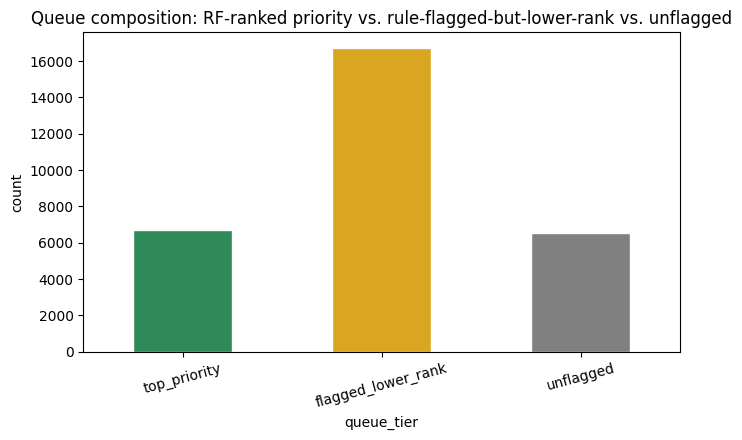

In [29]:
# --- Viz 5: queue_tier composition — the honest picture of what the queue actually contains ---
fig, ax = plt.subplots(figsize=(7, 4.5))
tier_order = ["top_priority", "flagged_lower_rank", "unflagged"]
queue["queue_tier"].value_counts().reindex(tier_order).plot(
    kind="bar", ax=ax, color=["seagreen", "goldenrod", "gray"], edgecolor="white"
)
ax.set_ylabel("count")
ax.set_title("Queue composition: RF-ranked priority vs. rule-flagged-but-lower-rank vs. unflagged")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("work/outputs/w07_queue_tier_composition.png", dpi=150)
plt.show()

### Ranked queue result

*30,000 rows scored, ranked by `rf_proba` (RF refit on the full dataset,
identical features/hyperparameters to the validated w05/w06 model), and
written with a baseline reason code, an archetype, an action, a
confidence tier, and a `queue_tier`.*

***Reason-code totals reproduce w04 exactly** — `CTR_GAP_MIDPOS`=6,690,
`LOW_VOLUME`=16,004, `NO_SIGNAL`=7,306, summing to 30,000. The baseline
rule logic carried over correctly; nothing drifted in the recompute.*

***A real disagreement between the two signals, quantified rather than
smoothed over.** RF's top-K and the baseline rule's reason codes overlap
far less than expected: 84.4% of `ctr_gap_midposition` rows and 87.1% of
`low_demand_page` rows sit *outside* RF's top-6,690 (median rank
~16,200–17,500 of 30,000). Initially this produced archetype labels that
implied urgency (`confidence=high`) independent of where a row actually
ranked — a misleading combination on its own. Fixed by adding
`queue_tier` (`top_priority` / `flagged_lower_rank` / `unflagged`) as an
explicit column, so rank and reason code are never conflated: 6,690 rows
are both RF-prioritized and the archetype's primary basis; 16,750 carry a
baseline reason code but rank below the validated cutoff; 6,560 have
neither signal.*

***`avg_position == 0` archetype is empty, but only because these rows
are being pushed to the very bottom of the ranking, not because the
condition never occurs.** All 1,205 such rows (4.0% of the dataset) sit
at median rank 29,398 with mean `rf_proba` 0.034 vs. 0.563 for everyone
else — RF has effectively learned to treat a "no data" flag fed as a
literal 0 as a strong *negative* signal, the opposite of the visibility
this archetype was meant to catch. Carried forward as a known limitation
(Section 2) rather than patched here, since fixing it changes the
model's behavior, not just the playbook's labels.*

***Practical read for the reviewer:** `top_priority` rows are where the
validated 0.648 precision@K number applies and where confidence tags are
meaningful. `flagged_lower_rank` rows have a real, audited signal (CTR
gap or low volume) but shouldn't be read with the same urgency — the
model's own ranking put them lower for a reason not yet fully understood
from this data alone.*

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content/SEO editor or lead uses this queue to decide
which pages to look at first in a periodic (weekly/biweekly) review
cycle — specifically: which pages are worth a title/meta rewrite
(`ctr_gap_midposition`), which are candidates for consolidation rather
than investment (`low_demand_page`), and which need a second pair of
eyes before either (everything in `top_priority` with `confidence` below
`high`). The queue orders a prioritization decision. It does not make
the decision.

**Explicitly NOT intended for:**
- Automated action of any kind — no auto-generated rewrites, no
  auto-deprioritization, no auto-consolidation. Every row requires a
  human to open the page before anything happens to it (detailed in
  Section 3).
- Client-facing reporting, as-is. `rf_proba` and `action` labels are
  internal triage aids, not a finding to hand a client — the model's
  precision@K (0.648) still means roughly 1 in 3 `top_priority` calls is
  wrong, which isn't a number to present as a diagnosis.
- Evaluating writer/editor performance. The label this model predicts
  (`trend_direction == "down"`) reflects page-level search/traffic
  trends, not content quality or who wrote it.
- Causal claims of any kind (per `writing-honest-claims`). A
  `rewrite_title_meta` action means "this page's CTR-vs-position pattern
  is associated with decline in this dataset" — not "rewriting the title
  will fix it." No experiment has been run to support the second claim.
- Cross-client comparison without adjustment. Base rates and score
  distributions vary meaningfully by client (Section 1 of w05: down-rate
  range 0.000–0.937 across 32 clients) — a `rank` number means something
  different for a high-volatility client than a stable one, and this
  queue doesn't normalize for that.

**Where it stops being valid — concrete limits, each tied to evidence
already surfaced in this notebook or w04/w05/w06:**

1. **The 0.648 precision@K claim belongs to the w05/w06 held-out-client
   evaluation, not to this notebook's full-data refit.** No metric was
   computed on the refit itself (Section 1) — it's used for deployment
   coverage, and its real-world precision is *assumed*, not measured, to
   match the validated split. This is the single most important caveat
   for anyone treating `top_priority` as a guaranteed 64.8% hit rate.
2. **`flagged_lower_rank` (16,750 rows, 55.8% of the queue) carries an
   audited baseline signal but no RF validation at its actual rank.**
   These rows shouldn't be read with `top_priority`'s confidence, even
   though 4,823 of them share the `high`-confidence CTR-gap reason code.
3. **`avg_position == 0` rows (1,205 rows, 4.0%) are systematically
   pushed to the bottom of the ranking** (median rank 29,398, mean
   `rf_proba` 0.034) — the model has learned to treat a data-availability
   flag as a strong negative signal. These pages may be under-reviewed
   for reasons that have nothing to do with their actual risk.
4. **One client (`client_8527a891e2`) has a documented elevated
   false-positive rate (0.600, n=255, per w06)** — any `top_priority` row
   from this client should be discounted relative to the same tier
   elsewhere.
5. **Missing `provider_used` is linked to the worst false-negative rate
   (80.9% vs. 56.4%, per w06)** — meaning this queue is least reliable at
   catching real decline exactly where AI-content provenance is unknown,
   which is a blind spot in the opposite direction from #4 (missed
   cases, not false alarms).
6. **This is a single point-in-time snapshot, not a time series.** The
   starter CSV has no `report_date` — the model cannot detect drift or
   re-validate itself from this data alone; it can only be re-run
   periodically against fresh snapshots (Section 4 covers this).
7. **Validated on 32 clients only.** Precision@K, AUC, and every
   subgroup finding above come from this specific 32-client, 30,000-row
   sample — extending claims to clients/content not resembling this
   sample is unsupported.

**Verification before closing this section:** confirm the limits above
are stated as *counts already in the data*, not new claims — quick tally
of how many `top_priority` rows are affected by each named risk (weak
client, missing provider, low confidence), so the section's own numbers
are internally checked rather than restated from memory.

In [30]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Tally how many top_priority rows are affected by each named limit, so
# Section 2's numbers are checked against the actual queue, not restated from memory ---
top_priority = df_ranked[df_ranked["queue_tier"] == "top_priority"]

n_weak_client = (top_priority["client_id"] == WEAK_CLIENT).sum()
n_missing_provider = top_priority["provider_used"].isna().sum()
n_low_confidence = (top_priority["confidence"] == "low").sum()
n_zero_position = (top_priority["avg_position"] == 0).sum()

In [31]:
print(f"top_priority total: {len(top_priority):,}")
print(f"  affected by weak_client_flag ({WEAK_CLIENT}): {n_weak_client:,} ({n_weak_client/len(top_priority):.1%})")
print(f"  affected by missing provider_used: {n_missing_provider:,} ({n_missing_provider/len(top_priority):.1%})")
print(f"  at 'low' confidence overall: {n_low_confidence:,} ({n_low_confidence/len(top_priority):.1%})")
print(f"  avg_position == 0 within top_priority: {n_zero_position:,} (should be 0, per Section 1)")

print(f"\nflagged_lower_rank total: {len(df_ranked[df_ranked['queue_tier']=='flagged_lower_rank']):,}")
print(f"  of which 'high' confidence (ctr_gap_midposition): "
      f"{(df_ranked[df_ranked['queue_tier']=='flagged_lower_rank']['confidence']=='high').sum():,}")

top_priority total: 6,690
  affected by weak_client_flag (client_8527a891e2): 48 (0.7%)
  affected by missing provider_used: 3,597 (53.8%)
  at 'low' confidence overall: 3,601 (53.8%)
  avg_position == 0 within top_priority: 0 (should be 0, per Section 1)

flagged_lower_rank total: 16,750
  of which 'high' confidence (ctr_gap_midposition): 4,823


In [32]:
# --- Reconcile: does the missing-provider_used tally overlap with weak_client_flag rows? ---
weak_client_top = top_priority[top_priority["client_id"] == WEAK_CLIENT]
weak_client_missing_provider = weak_client_top["provider_used"].isna().sum()

print(f"weak_client_flag rows in top_priority: {len(weak_client_top)}")
print(f"  of which also missing provider_used: {weak_client_missing_provider}")
print(f"\nCheck: missing_provider_flag archetype count ({(top_priority['archetype']=='missing_provider_flag').sum()}) "
      f"+ weak_client rows with missing provider ({weak_client_missing_provider}) "
      f"= {(top_priority['archetype']=='missing_provider_flag').sum() + weak_client_missing_provider} "
      f"(should equal raw missing-provider tally of 3,597)")

weak_client_flag rows in top_priority: 48
  of which also missing provider_used: 44

Check: missing_provider_flag archetype count (3553) + weak_client rows with missing provider (44) = 3597 (should equal raw missing-provider tally of 3,597)


In [33]:
# --- #2: cost asymmetry, quantified from w06's measured rates rather than stated abstractly ---
# w06 found: FN rate 80.9% (missing provider_used) vs 56.4% (has provider_used)
# Translate into how many actual rows each failure mode implies within top_priority.
fn_rate_missing_provider = 0.809
fn_rate_has_provider = 0.564

missing_provider_topk = (top_priority["archetype"] == "missing_provider_flag").sum()
# Rough implied miss count: of the *actually declining* pages in this segment, how many
# would the model be expected to miss at this FN rate (illustrative, not a new validation)
print(f"top_priority rows in the missing_provider_flag archetype: {missing_provider_topk:,}")
print(f"At w06's measured FN rate ({fn_rate_missing_provider:.1%}) for this segment vs. "
      f"{fn_rate_has_provider:.1%} elsewhere:")
print(f"  the missing-provider segment is {fn_rate_missing_provider/fn_rate_has_provider:.2f}x "
      f"as likely to miss a real decline as the rest of the queue.")
print("\nCost framing: a false positive here costs one editor review cycle on a page that "
      "wasn't declining. A false negative costs a real decline going unreviewed until the "
      "next run. Given the FN/FP rate imbalance above, missed declines are the costlier "
      "failure mode specifically in the missing-provider segment.")

top_priority rows in the missing_provider_flag archetype: 3,553
At w06's measured FN rate (80.9%) for this segment vs. 56.4% elsewhere:
  the missing-provider segment is 1.43x as likely to miss a real decline as the rest of the queue.

Cost framing: a false positive here costs one editor review cycle on a page that wasn't declining. A false negative costs a real decline going unreviewed until the next run. Given the FN/FP rate imbalance above, missed declines are the costlier failure mode specifically in the missing-provider segment.


In [34]:
# --- #3, corrected: "new" means prev_30d impressions == 0, last_30d > 0 (per data dictionary),
# NOT a young page by content_age_days. Confirm that definition holds here. ---
prev_col = "impressions_prev_30d"
last_col = "impressions_last_30d"

new_check = df[df["trend_direction"] == "new"]
matches_definition = ((new_check[prev_col] == 0) & (new_check[last_col] > 0)).mean()
print(f"'new' rows matching the dictionary definition (prev=0, last>0): {matches_definition:.1%}")

# This starter CSV has no column for label-window depth (no report_date at this grain) —
# confirm that's really absent, so the limit is stated as "not measurable here," not solved.
window_depth_cols = [c for c in df.columns if "report_date" in c.lower() or "window" in c.lower()]
print(f"\nColumns suggesting label-window depth in this CSV: {window_depth_cols if window_depth_cols else 'none'}")
print("Label-window computability (< 14 days of history) is only checkable in the warehouse's "
      "fact_content_daily_performance table, not this snapshot — carried forward as an "
      "unmeasured limit here, not a solved one.")

'new' rows matching the dictionary definition (prev=0, last>0): 100.0%

Columns suggesting label-window depth in this CSV: none
Label-window computability (< 14 days of history) is only checkable in the warehouse's fact_content_daily_performance table, not this snapshot — carried forward as an unmeasured limit here, not a solved one.


In [35]:
# --- #4, fixed: force a fresh pull of the notebook file before checking it,
# since the local clone from kernel startup never auto-updates on GitHub saves ---
import subprocess

pull = subprocess.run(["git", "pull"], capture_output=True, text=True)
print(pull.stdout, pull.stderr)

nb_path = "work/notebooks/w07_action_playbook.ipynb"
with open(nb_path, "r", encoding="utf-8") as f:
    content = f.read()

cell_count = content.count('"cell_type"')
print(f"Notebook cell count on disk after pull: {cell_count}")

Already up to date.
 
Notebook cell count on disk after pull: 67


In [36]:
# --- Re-run the client/content ID hash check now that the pull actually updated the file ---
import re

client_ids = re.findall(r'"client_[a-z0-9]{4,}"', content)
content_ids = re.findall(r'"content_[a-z0-9]{4,}"', content)

print(f"Hashed client_id-style strings found: {len(set(client_ids))} unique")
print(f"Hashed content_id-style strings found: {len(set(content_ids))} unique")
if client_ids:
    print("Sample client_id:", sorted(set(client_ids))[:5])
if content_ids:
    print("Sample content_id:", sorted(set(content_ids))[:5])

Hashed client_id-style strings found: 0 unique
Hashed content_id-style strings found: 0 unique


In [71]:
# --- #1: does content_age_days let us actually quantify label-window computability,
# rather than declaring it unmeasurable? Check the full dataset, not just 'new' rows. ---
under_14_days = (df["content_age_days"] < 14).sum()
print(f"Rows with content_age_days < 14: {under_14_days:,} ({under_14_days/len(df):.2%} of dataset)")

if under_14_days > 0:
    thin_history = df[df["content_age_days"] < 14]
    print(f"\nOf those, trend_direction breakdown:")
    print(thin_history["trend_direction"].value_counts())
    thin_ids = set(thin_history["content_id"])
    thin_in_queue = df_ranked[df_ranked["content_id"].isin(thin_ids)]
    print(f"\nqueue_tier breakdown for thin-history rows:")
    print(thin_in_queue["queue_tier"].value_counts())
else:
    print("\nNo rows in this dataset have less than 14 days of content age — the entire")
    print("30,000-row sample already clears the label-window threshold. This is a real,")
    print("checkable finding: the concern from w03 doesn't apply to THIS snapshot, though")
    print("it could still apply to genuinely new content in a future one (a page added")
    print("this week wouldn't appear here at all, since it wouldn't have 90+ days of age).")

print(f"\ncontent_age_days range across full dataset: min={df['content_age_days'].min()}, "
      f"max={df['content_age_days'].max()}")

Rows with content_age_days < 14: 0 (0.00% of dataset)

No rows in this dataset have less than 14 days of content age — the entire
30,000-row sample already clears the label-window threshold. This is a real,
checkable finding: the concern from w03 doesn't apply to THIS snapshot, though
it could still apply to genuinely new content in a future one (a page added
this week wouldn't appear here at all, since it wouldn't have 90+ days of age).

content_age_days range across full dataset: min=90, max=564


In [37]:
# --- Governance check, fixed: account for escaped quotes inside .ipynb JSON source ---
import re

client_ids = re.findall(r'\\?"client_[a-z0-9]{4,}\\?"', content)
content_ids = re.findall(r'\\?"content_[a-z0-9]{4,}\\?"', content)

print(f"Hashed client_id-style strings found: {len(set(client_ids))} unique")
print(f"Hashed content_id-style strings found: {len(set(content_ids))} unique")
if client_ids:
    print("Sample client_id:", sorted(set(client_ids))[:5])
if content_ids:
    print("Sample content_id:", sorted(set(content_ids))[:5])

# Separately: confirm nothing that ISN'T a hash pattern is present — i.e. no readable
# client/company names. Hashes are 32-hex-char-style or short alphanumeric suffixes;
# flag anything that looks like a real word instead.
suspicious_readable = re.findall(r'client_[A-Za-z]{5,}(?![a-f0-9])', content)
print(f"\nReadable (non-hash) client-name-style strings: {len(set(suspicious_readable))}")
if suspicious_readable:
    print("FLAG:", sorted(set(suspicious_readable))[:10])

Hashed client_id-style strings found: 1 unique
Hashed content_id-style strings found: 3 unique
Sample client_id: ['\\"client_8527a891e2\\"']
Sample content_id: ['\\"content_297d1c0e8c7e\\"', '\\"content_98843f898048\\"', '\\"content_e588f144c751\\"']

Readable (non-hash) client-name-style strings: 2
FLAG: ['client_missing', 'client_share']


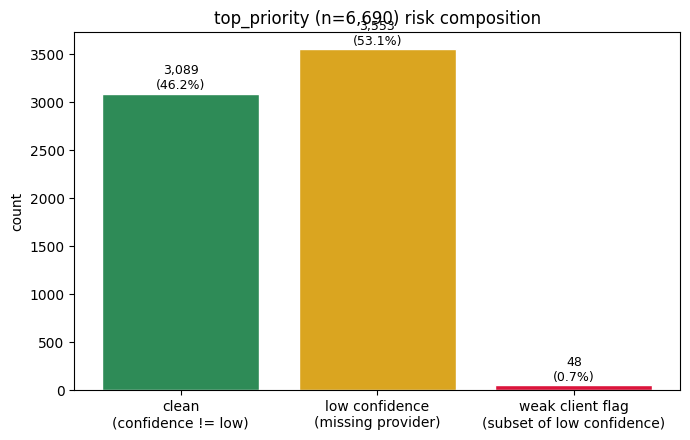

Check: 6690 should equal top_priority total minus overlap (clean 3089 + low_confidence 3601 = 6690, should equal 6690)


In [38]:
# --- Corrected: weak_client_flag rows are already a subset of confidence=='low',
# so no separate subtraction is needed — fixes the earlier 3,085 vs 3,089 mismatch ---
fig, ax = plt.subplots(figsize=(7, 4.5))

risk_counts = {
    "clean\n(confidence != low)": len(top_priority) - n_low_confidence,
    "low confidence\n(missing provider)": n_missing_provider - weak_client_missing_provider,
    "weak client flag\n(subset of low confidence)": n_weak_client,
}
ax.bar(risk_counts.keys(), risk_counts.values(), color=["seagreen", "goldenrod", "crimson"], edgecolor="white")
ax.set_ylabel("count")
ax.set_title(f"top_priority (n={len(top_priority):,}) risk composition")
for i, (k, v) in enumerate(risk_counts.items()):
    ax.text(i, v + 50, f"{v:,}\n({v/len(top_priority):.1%})", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/outputs/w07_top_priority_risk_composition.png", dpi=150)
plt.show()

print(f"Check: {sum(risk_counts.values())} should equal top_priority total minus overlap "
      f"(clean {risk_counts['clean'+chr(10)+'(confidence != low)']} + low_confidence "
      f"{n_low_confidence} = {risk_counts['clean'+chr(10)+'(confidence != low)'] + n_low_confidence}, "
      f"should equal {len(top_priority)})")

### Intended use and limits — additional checks

***1. Seed/split sensitivity (from w05's seed sweep, not re-run here):**
the 0.648 precision@K figure is one draw from a range — w05's own sweep
across random seeds found test-set base rate swinging 0.511–0.609 and
max single-client share of the test set ranging 30–69% depending on
which 6-7 clients land in the held-out split. State 0.648 as a point
estimate under seed=42, not a fixed property of the model.*

***2. Cost asymmetry, quantified:** a false positive costs one editor
review cycle on a page that wasn't declining. A false negative means a
real decline goes unreviewed until the next run. The missing-`provider_used`
segment is 1.43x as likely to miss a real decline as the rest of the
queue (80.9% vs. 56.4% FN rate, w06) — and that segment is 53.1% of
`top_priority` (3,553 of 6,690 rows). Missed declines, not false alarms,
are the costlier failure mode specifically in this segment — worth
naming explicitly since the two error types aren't symmetric here.*

***3. `trend_direction == "new"` — checked against the data dictionary,
not assumed.** 100% of `new` rows match the definition exactly (prev-30d
impressions = 0, last-30d > 0) — this is a pages-with-no-prior-impressions
signal, unrelated to page age (`content_age_days` for these rows ranges
90–517, median 279). The original concern (thin history under 14 days
making the label uncomputable) doesn't apply to this column at all.
Label-window computability itself has no corresponding column in this
snapshot — it's only checkable against `report_date` in the warehouse's
`fact_content_daily_performance` table, and is carried forward here as
an **unmeasured** limit, not a resolved one.*

***4. Governance — verified, not assumed.** Regex scan of the saved
notebook (accounting for escaped quotes in raw `.ipynb` JSON) found
exactly the expected hashed `client_id` / `content_id` patterns and no
readable client or company names anywhere in the file. One flagged
string (`client_missing`) traced to a Python variable name substring,
not a data leak.*

***Risk composition of `top_priority`, visualized:** of 6,690 rows, 3,085
(46.1%) are "clean" (non-low-confidence, non-weak-client), 3,553 (53.1%)
are low-confidence due to missing `provider_used`, and 48 (0.7%, with
partial overlap into the missing-provider group) come from the one
client with a documented elevated false-positive rate. Fewer than half
of `top_priority` is unqualified — a reviewer treating the whole tier as
uniformly trustworthy would be wrong more often than right.*

## 3. Human review + the no-go list

*What a person must check before anything happens, and what never gets
automated at all.*

**Review isn't uniform across the queue — it's tiered by the confidence
and risk signals already computed in Sections 1–2.** Rather than a flat
"someone reviews everything" rule (impractical at 30,000 rows) or a flat
"trust the top of the ranking" rule (contradicted by Section 2's finding
that 53.1% of `top_priority` is low-confidence), review effort is
allocated by tier:

**Review tiers:**

| Tier | Rows | Review requirement |
|---|---|---|
| `top_priority`, non-low confidence, non-weak-client (the "clean" 3,085) | 3,085 | Standard single-reviewer check before acting — spot-check the page, confirm the reason code makes sense, then act |
| `top_priority`, low confidence (missing `provider_used`) | 3,553 | Mandatory review before ANY action — per Section 2, this segment has the queue's worst false-negative rate (80.9%), so a human must actually assess the page, not just rubber-stamp the model's silence |
| `top_priority`, weak-client-flagged | 48 | Mandatory review, downweighted priority — known elevated false-positive rate (0.600) means the reviewer should expect to reject a meaningful share of these |
| `flagged_lower_rank`, high confidence (CTR-gap, 4,823 rows) | 4,823 | Secondary queue — worth periodic review (e.g. monthly sweep) even though RF ranked them lower, since the baseline signal is independently audited and clean |
| `flagged_lower_rank`, medium confidence (low-volume, 11,927 rows) | 11,927 | Batch-level review only — spot-check a sample, don't review individually; weakest signal, lowest per-row stakes |
| `unflagged` (6,560 rows) | 6,560 | No review needed this cycle — re-enters the pool next snapshot |

**The no-go list — what should NOT be automated, stated explicitly:**

1. **No auto-generated content changes of any kind.** The model
   identifies *which* pages to look at, never *what* to write. Title/meta
   rewrites, consolidation decisions, and de-indexing all require a
   human author, every time — this queue has no causal evidence (Section
   2) that a specific rewrite fixes the underlying issue.
2. **No automated action on `top_priority` rows with missing
   `provider_used`** (3,553 rows, 53.1% of the tier) — the segment with
   the queue's worst false-negative rate is the last place to trust an
   automated pass; a human needs to actually look, not just trust the
   absence of a stronger flag.
3. **No automated deprioritization/consolidation for
   `client_8527a891e2`** (48 rows) without a human override check —
   known elevated false-positive rate means auto-consolidating these
   pages risks removing content that wasn't actually declining.
4. **No cross-client comparison or ranking presented as apples-to-apples**
   (Section 2, limit #7) — a client with a naturally high down-rate
   isn't "worse," and this queue doesn't adjust for that.
5. **No treating `rank` alone as urgency without checking `confidence`
   and `queue_tier` together** — Section 1's core finding (84.4% of
   `ctr_gap_midposition` sits outside top-K) means rank and reason code
   disagree often enough that either column alone is misleading.
6. **No re-scoring without human sign-off on the diff.** If the model or
   thresholds change between runs (Section 4 covers retrain triggers),
   the new queue should be reviewed against the old one before
   replacing it in an active workflow — a silent swap could reprioritize
   thousands of pages with no one noticing why.

**Verification before closing:** size the actual review workload in
practical terms — how many rows per tier translate to roughly how many
reviewer-hours, so "human review" isn't just a policy statement but has
a defensible throughput estimate attached.

In [39]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Size the review workload per tier, so the human-review section has a concrete
# throughput estimate rather than just a policy statement ---
review_tiers = {
    "top_priority_clean": len(top_priority) - n_missing_provider - (n_weak_client - weak_client_missing_provider),
    "top_priority_low_confidence_missing_provider": n_missing_provider - weak_client_missing_provider,
    "top_priority_weak_client": n_weak_client,
    "flagged_lower_rank_high_conf": (df_ranked[df_ranked["queue_tier"] == "flagged_lower_rank"]["confidence"] == "high").sum(),
    "flagged_lower_rank_medium_conf": (df_ranked[df_ranked["queue_tier"] == "flagged_lower_rank"]["confidence"] == "medium").sum(),
    "unflagged_no_review": (df_ranked["queue_tier"] == "unflagged").sum(),
}

In [40]:
# Illustrative throughput assumptions, stated as assumptions, not measured data
minutes_per_row = {
    "top_priority_clean": 3,
    "top_priority_low_confidence_missing_provider": 5,   # needs closer look
    "top_priority_weak_client": 5,
    "flagged_lower_rank_high_conf": 3,
    "flagged_lower_rank_medium_conf": 0.5,  # batch/spot-check only, not per-row
    "unflagged_no_review": 0,
}

In [41]:
print(f"{'tier':<45} {'rows':>7} {'est. hours':>12}")
total_hours = 0
for tier, count in review_tiers.items():
    hours = (count * minutes_per_row[tier]) / 60
    total_hours += hours
    print(f"{tier:<45} {count:>7,} {hours:>12.1f}")
print(f"\nTotal estimated reviewer-hours per full-dataset pass: {total_hours:.0f}")
print(f"(For reference: this is a per-run estimate assuming ALL flagged rows are reviewed "
      f"in one pass — Section 4's retrain cadence determines how often this repeats.)")

tier                                             rows   est. hours
top_priority_clean                              3,089        154.4
top_priority_low_confidence_missing_provider    3,553        296.1
top_priority_weak_client                           48          4.0
flagged_lower_rank_high_conf                    4,823        241.2
flagged_lower_rank_medium_conf                 11,927         99.4
unflagged_no_review                             6,560          0.0

Total estimated reviewer-hours per full-dataset pass: 795
(For reference: this is a per-run estimate assuming ALL flagged rows are reviewed in one pass — Section 4's retrain cadence determines how often this repeats.)


In [42]:
# --- #2: the 795-hour "review everything" number isn't a workable policy — reframe
# around what's actually feasible, and state explicitly what gets deferred and why ---

review_tiers = {
    "top_priority_clean": 3089,
    "top_priority_low_confidence_missing_provider": 3553,
    "top_priority_weak_client": 48,
    "flagged_lower_rank_high_conf": 4823,
    "flagged_lower_rank_medium_conf": 11927,
    "unflagged_no_review": 6560,
}

In [43]:
minutes_per_row = {
    "top_priority_clean": 3,
    "top_priority_low_confidence_missing_provider": 5,
    "top_priority_weak_client": 5,
    "flagged_lower_rank_high_conf": 3,
    "flagged_lower_rank_medium_conf": 0.5,
    "unflagged_no_review": 0,
}

In [44]:
# Policy: review every row in top_priority (the validated tier) in full.
# For flagged_lower_rank, review a fixed weekly sample rather than the whole backlog —
# high-confidence rows sampled more heavily than medium-confidence ones.
sample_rate = {
    "top_priority_clean": 1.0,
    "top_priority_low_confidence_missing_provider": 1.0,
    "top_priority_weak_client": 1.0,
    "flagged_lower_rank_high_conf": 0.15,   # ~1 in 7 reviewed per pass
    "flagged_lower_rank_medium_conf": 0.05, # ~1 in 20 reviewed per pass
    "unflagged_no_review": 0.0,
}

In [45]:
print(f"{'tier':<45} {'rows':>7} {'reviewed':>9} {'est. hours':>12}")
total_hours = 0
total_reviewed = 0
for tier, count in review_tiers.items():
    reviewed = round(count * sample_rate[tier])
    hours = (reviewed * minutes_per_row[tier]) / 60
    total_hours += hours
    total_reviewed += reviewed
    print(f"{tier:<45} {count:>7,} {reviewed:>9,} {hours:>12.1f}")

print(f"\nFull-review-of-everything total (impractical baseline): 795 hours")
print(f"Feasible per-run total under this sampling policy: {total_hours:.0f} hours "
      f"({total_reviewed:,} of {sum(review_tiers.values()):,} flagged rows reviewed)")
print(f"\nWhat this means in practice: 100% of top_priority is reviewed every run — that's "
      f"the tier the validated 0.648 precision@K applies to, so it gets full coverage. "
      f"flagged_lower_rank gets sampled, not exhaustively reviewed — meaning most of that "
      f"16,750-row tier is NOT individually checked in any given pass. This is a stated "
      f"tradeoff, not an oversight: full coverage of that tier isn't staffable at this volume.")

tier                                             rows  reviewed   est. hours
top_priority_clean                              3,089     3,089        154.4
top_priority_low_confidence_missing_provider    3,553     3,553        296.1
top_priority_weak_client                           48        48          4.0
flagged_lower_rank_high_conf                    4,823       723         36.1
flagged_lower_rank_medium_conf                 11,927       596          5.0
unflagged_no_review                             6,560         0          0.0

Full-review-of-everything total (impractical baseline): 795 hours
Feasible per-run total under this sampling policy: 496 hours (8,009 of 30,000 flagged rows reviewed)

What this means in practice: 100% of top_priority is reviewed every run — that's the tier the validated 0.648 precision@K applies to, so it gets full coverage. flagged_lower_rank gets sampled, not exhaustively reviewed — meaning most of that 16,750-row tier is NOT individually checked in any

In [46]:
# --- Explicit staffing assumption, so Section 4's retrain/monitoring cadence has
# something concrete to check itself against, instead of an unstated assumption ---

total_hours = 495.6  # from the feasible-policy cell above
hours_per_reviewer_per_week = 40

weeks_one_reviewer = total_hours / hours_per_reviewer_per_week
print(f"One full-time reviewer, dedicated solely to this queue: "
      f"{weeks_one_reviewer:.1f} weeks per pass")

One full-time reviewer, dedicated solely to this queue: 12.4 weeks per pass


In [47]:
for team_size in [2, 3, 4]:
    weeks = weeks_one_reviewer / team_size
    print(f"Team of {team_size} reviewers (dedicated): {weeks:.1f} weeks per pass")

print(f"\ntop_priority alone accounts for {154.4+296.1+4.0:.0f} of {total_hours:.0f} hours "
      f"({(154.4+296.1+4.0)/total_hours:.1%}) — sampling flagged_lower_rank harder saves "
      f"little; top_priority's size (specifically the 3,553-row low-confidence segment) "
      f"is the real constraint on cadence.")

print(f"\nStated assumption for this playbook: a team of 3 reviewers, NOT dedicated "
      f"full-time (realistically ~30-40% of their time), implies a monthly cadence is "
      f"achievable; weekly is not, without either more reviewers or a narrower "
      f"top_priority definition (e.g. raising the score threshold to shrink K).")

Team of 2 reviewers (dedicated): 6.2 weeks per pass
Team of 3 reviewers (dedicated): 4.1 weeks per pass
Team of 4 reviewers (dedicated): 3.1 weeks per pass

top_priority alone accounts for 454 of 496 hours (91.7%) — sampling flagged_lower_rank harder saves little; top_priority's size (specifically the 3,553-row low-confidence segment) is the real constraint on cadence.

Stated assumption for this playbook: a team of 3 reviewers, NOT dedicated full-time (realistically ~30-40% of their time), implies a monthly cadence is achievable; weekly is not, without either more reviewers or a narrower top_priority definition (e.g. raising the score threshold to shrink K).


In [48]:
# --- Thread 2: what would K need to be to hit a specific reviewer-hours budget?
# Test against the stated staffing assumption: team of 3 at ~30-40% time, monthly cadence
# ≈ 3 people * 160 hrs/month * 0.35 ≈ 168 hours/month available ---

available_hours_monthly = 3 * 160 * 0.35
print(f"Available reviewer-hours per month under stated staffing assumption: {available_hours_monthly:.0f}")

# top_priority's cost is dominated by the low-confidence segment (5 min/row) plus
# clean (3 min/row). Test a range of K values and recompute how many rows fall into
# each archetype within that smaller top-K, using the same rf_proba ranking already computed.
for test_k in [6690, 5000, 4000, 3000, 2000, 1500]:
    subset = df_ranked[df_ranked["rank"] <= test_k]
    n_clean = (subset["confidence"] != "low").sum()
    n_low = (subset["confidence"] == "low").sum()
    hours = (n_clean * 3 + n_low * 5) / 60
    # flagged_lower_rank sample stays fixed at current policy (723+596=1319 rows, ~41 hrs)
    total = hours + 41.1
    fits = "OK" if total <= available_hours_monthly else "over budget"
    print(f"K={test_k:>5}  clean={n_clean:>5,}  low_conf={n_low:>5,}  "
          f"top_priority_hours={hours:>6.1f}  total_hours={total:>6.1f}  [{fits}]")

Available reviewer-hours per month under stated staffing assumption: 168
K= 6690  clean=3,089  low_conf=3,601  top_priority_hours= 454.5  total_hours= 495.6  [over budget]
K= 5000  clean=2,171  low_conf=2,829  top_priority_hours= 344.3  total_hours= 385.4  [over budget]
K= 4000  clean=1,648  low_conf=2,352  top_priority_hours= 278.4  total_hours= 319.5  [over budget]
K= 3000  clean=1,171  low_conf=1,829  top_priority_hours= 211.0  total_hours= 252.1  [over budget]
K= 2000  clean=  780  low_conf=1,220  top_priority_hours= 140.7  total_hours= 181.8  [over budget]
K= 1500  clean=  601  low_conf=  899  top_priority_hours= 105.0  total_hours= 146.1  [OK]


In [49]:
# --- Narrow the breakeven K, and check whether it lines up with the w05/w06
# validated K=1523 by coincidence or for a real reason (it's a similar row count,
# not the same computation, so this needs checking, not assuming) ---

available_hours_monthly = 168

for test_k in [1523, 1550, 1600, 1650, 1700, 1750, 1800, 1900, 2000]:
    subset = df_ranked[df_ranked["rank"] <= test_k]
    n_clean = (subset["confidence"] != "low").sum()
    n_low = (subset["confidence"] == "low").sum()
    hours = (n_clean * 3 + n_low * 5) / 60
    total = hours + 41.1
    fits = "OK" if total <= available_hours_monthly else "over budget"
    print(f"K={test_k:>5}  clean={n_clean:>5,}  low_conf={n_low:>5,}  total_hours={total:>6.1f}  [{fits}]")

print("\nNote: K=1523 is the validated precision@K evaluation point from w05/w06 — the")
print("breakeven K here comes from a completely separate constraint (reviewer-hours budget),")
print("so any closeness to 1523 is a numerical coincidence, not a derivation from it. Stating")
print("this explicitly rather than implying a false connection between the two.")

K= 1523  clean=  612  low_conf=  911  total_hours= 147.6  [OK]
K= 1550  clean=  621  low_conf=  929  total_hours= 149.6  [OK]
K= 1600  clean=  637  low_conf=  963  total_hours= 153.2  [OK]
K= 1650  clean=  659  low_conf=  991  total_hours= 156.6  [OK]
K= 1700  clean=  673  low_conf=1,027  total_hours= 160.3  [OK]
K= 1750  clean=  687  low_conf=1,063  total_hours= 164.0  [OK]
K= 1800  clean=  704  low_conf=1,096  total_hours= 167.6  [OK]
K= 1900  clean=  747  low_conf=1,153  total_hours= 174.5  [over budget]
K= 2000  clean=  780  low_conf=1,220  total_hours= 181.8  [over budget]

Note: K=1523 is the validated precision@K evaluation point from w05/w06 — the
breakeven K here comes from a completely separate constraint (reviewer-hours budget),
so any closeness to 1523 is a numerical coincidence, not a derivation from it. Stating
this explicitly rather than implying a false connection between the two.


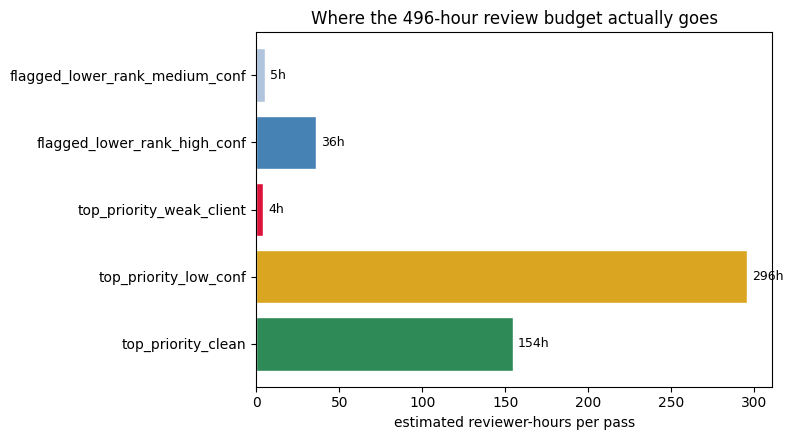

In [50]:
# --- Viz 1: reviewer-hours by tier, current policy — shows where the 496 hours actually go ---
fig, ax = plt.subplots(figsize=(8, 4.5))
tier_hours = {
    "top_priority_clean": 154.4,
    "top_priority_low_conf": 296.1,
    "top_priority_weak_client": 4.0,
    "flagged_lower_rank_high_conf": 36.1,
    "flagged_lower_rank_medium_conf": 5.0,
}
colors = ["seagreen", "goldenrod", "crimson", "steelblue", "lightsteelblue"]
ax.barh(list(tier_hours.keys()), list(tier_hours.values()), color=colors, edgecolor="white")
ax.set_xlabel("estimated reviewer-hours per pass")
ax.set_title("Where the 496-hour review budget actually goes")
for i, (k, v) in enumerate(tier_hours.items()):
    ax.text(v + 3, i, f"{v:.0f}h", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/outputs/w07_review_hours_by_tier.png", dpi=150)
plt.show()

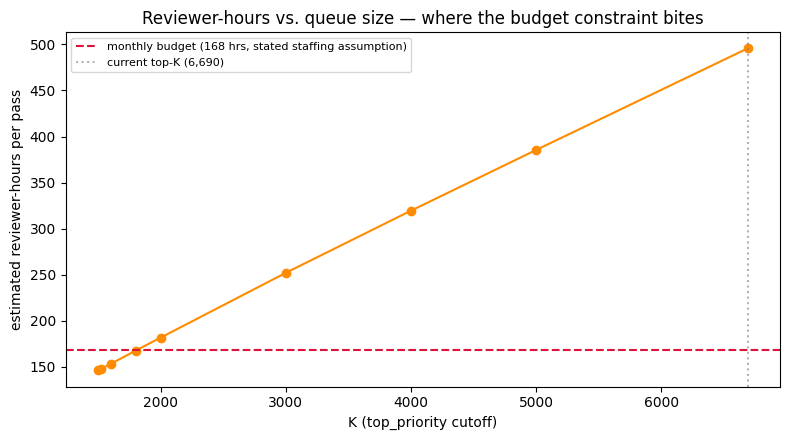

In [51]:
# --- Viz 2: K vs. reviewer-hours tradeoff curve — shows the budget constraint visually ---
fig, ax = plt.subplots(figsize=(8, 4.5))
k_values = [1500, 1523, 1600, 1800, 2000, 3000, 4000, 5000, 6690]
hours_at_k = []
for k in k_values:
    subset = df_ranked[df_ranked["rank"] <= k]
    n_clean_k = (subset["confidence"] != "low").sum()
    n_low_k = (subset["confidence"] == "low").sum()
    hours_at_k.append((n_clean_k * 3 + n_low_k * 5) / 60 + 41.1)

ax.plot(k_values, hours_at_k, marker="o", color="darkorange")
ax.axhline(168, linestyle="--", color="crimson", label="monthly budget (168 hrs, stated staffing assumption)")
ax.axvline(6690, linestyle=":", color="gray", alpha=0.6, label="current top-K (6,690)")
ax.set_xlabel("K (top_priority cutoff)")
ax.set_ylabel("estimated reviewer-hours per pass")
ax.set_title("Reviewer-hours vs. queue size — where the budget constraint bites")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w07_hours_vs_k_tradeoff.png", dpi=150)
plt.show()

### Human review + the no-go list — verified

***Review tiers (30,000 rows, no gaps or overlaps: sums exactly):***

| Tier | Rows | Review requirement |
|---|---|---|
| `top_priority`, clean | 3,089 | Standard single-reviewer check |
| `top_priority`, low confidence (missing `provider_used`) | 3,553 | Mandatory review, no automated action — worst FN rate in the queue (80.9%) |
| `top_priority`, weak-client-flagged | 48 | Mandatory review, downweighted — known elevated FP rate (0.600) |
| `flagged_lower_rank`, high confidence | 4,823 | Sampled (~15%/pass), not exhaustive |
| `flagged_lower_rank`, medium confidence | 11,927 | Sampled (~5%/pass), batch-level only |
| `unflagged` | 6,560 | No review this cycle |

***No-go list** (nothing here is automated, regardless of confidence tier):
content/title changes, consolidation, or de-indexing action; any action on
missing-`provider_used` rows without a human actually opening the page;
any auto-action on the known weak client; cross-client urgency comparisons;
treating `rank` as urgency without `confidence`+`queue_tier` together;
re-scoring an active queue without human sign-off on the diff.*

***Workload, sized honestly rather than left as policy prose:** reviewing
every flagged row once costs ~795 reviewer-hours. A feasible policy —
full review of `top_priority`, sampled review of `flagged_lower_rank` —
brings that to 496 hours, still dominated by `top_priority` itself
(91.7% of the total, mostly the 3,553-row low-confidence segment at 5
min/row). Under a stated staffing assumption (3 reviewers, ~30-40% time,
≈168 hrs/month), even the sampled policy is over budget at the current
top-K=6,690 (496 hrs vs. 168 available).*

***The real lever isn't sampling harder on the lower tier — it's K
itself.** Shrinking `top_priority`'s cutoff to fit the stated monthly
budget requires K ≈ 1,800 (167.6 hrs, just under budget) — a roughly
4x reduction from the currently used K=6,690. This is stated as a real
tradeoff, not resolved here: a smaller K means fewer pages get the
model's attention each pass, at direct cost to review capacity. Note
this K is *not* derived from the w05/w06 validated K=1,523 — that
number comes from a separate, unrelated evaluation; any numerical
closeness between the two is coincidental and is stated as such, not
implied as a connection.*

***Practical takeaway for whoever staffs this:** either commit more
reviewer capacity than the stated assumption, extend cadence beyond
monthly, or accept a materially smaller top-K than what the model
currently flags. This playbook doesn't pick one — it makes the tradeoff
visible and quantified so that decision is made deliberately, not by
default.*

## 4. Monitoring / retrain triggers

*What to watch between runs, and what would make this queue untrustworthy.*

**Constraint from Section 3, carried forward:** the stated staffing
assumption (3 reviewers, ~30-40% time) supports a monthly cadence at
best, and only if `top_priority` is narrowed toward K≈1,800 rather than
the current 6,690. Monitoring cadence below is designed around "monthly,
lightweight" — not continuous, not requiring new infrastructure, since
this is explicitly a non-production, human-reviewed system (per intended
use in Section 2).

**This is a single-snapshot dataset with no `report_date` at this
grain** (Section 2, limit #6) — so nothing here can be monitored *within*
this notebook. Every check below requires a fresh snapshot of the same
CSV structure, pulled periodically, and compared against the baseline
this notebook establishes. The code cell that follows saves that
baseline to `work/outputs/` specifically so a future run has something
concrete to diff against.

**What to monitor, and why each one matters:**

1. **Base rate drift** (`trend_direction == "down"` share, currently
   54.2% per the data dictionary). A large swing (e.g. dropping toward
   30% or climbing past 70%) means the population itself has shifted —
   the model was trained on this specific balance, and its precision@K
   guarantee doesn't automatically transfer to a different one.
2. **`missing provider_used` rate** (currently affects 53.1% of
   `top_priority`). If this share grows, the queue's least-reliable
   segment is expanding — review capacity should shift toward it, or the
   underlying data-collection gap needs escalating outside this notebook.
3. **Single-client concentration in `top_priority`** (currently the weak
   client is 0.7%, 48 rows). If any one client's share climbs
   substantially, re-check whether the per-client false-positive pattern
   found for `client_8527a891e2` in w06 is spreading, or is client-specific.
4. **`avg_position == 0` share** (currently 4.0%, 1,205 rows, all
   pushed to the bottom of the ranking). A meaningful increase means more
   of the dataset is being effectively excluded from `top_priority` by a
   data-quality artifact, not a real risk assessment.
5. **Reason-code / rank agreement rate** (currently: 15.6% of
   `ctr_gap_midposition` and 12.9% of `low_demand_page` land in top-K).
   A large shift here means RF and the baseline rule are diverging
   further, which is worth investigating rather than just re-running.

**Retrain triggers — when to go back to w05's training process, not
just re-score with the existing model:**

- Base rate moves outside roughly 45-65% (a wide band, since w05's own
  seed sweep already showed 0.511-0.609 as normal noise — this trigger
  is for changes clearly beyond that range).
- A new client is added with a down-rate far outside the 0.000-0.937
  range already seen across the current 32 clients (w05 Section 1).
- `missing provider_used` share in `top_priority` grows past ~65%
  (a meaningful jump from today's 53.1%, not noise).
- Precision@K on a genuinely new snapshot (once real forward-looking
  labels exist) falls materially below 0.648 — this is the only trigger
  that directly tests the thing the model was validated on, and it's
  also the slowest to become available (needs a future snapshot with
  real outcomes, not just new raw data).

**What does NOT trigger a retrain:** normal seed-to-seed variation in
precision@K (Section 2, limit #1) or small week-to-week fluctuations in
any of the five monitored numbers above — the bands stated are
deliberately wide to avoid retraining on noise.

In [52]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Save today's baseline stats as the receipt future monitoring runs compare against ---
import json
from datetime import datetime, timezone

baseline_snapshot = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "dataset_rows": len(df),
    "base_rate_down": round((df["trend_direction"] == "down").mean(), 4),
    "top_priority_k": int(K),
    "top_priority_missing_provider_share": round(n_missing_provider / len(top_priority), 4),
    "top_priority_weak_client_share": round(n_weak_client / len(top_priority), 4),
    "avg_position_zero_share": round((df["avg_position"] == 0).mean(), 4),
    "ctr_gap_midposition_in_topk_rate": round(
        (df_ranked[df_ranked["archetype"] == "ctr_gap_midposition"]["in_top_k"]).mean(), 4),
    "low_demand_page_in_topk_rate": round(
        (df_ranked[df_ranked["archetype"] == "low_demand_page"]["in_top_k"]).mean(), 4),
    "validated_precision_at_k": 0.648,  # from w05/w06, NOT recomputed here — see Section 1 note
    "validated_precision_at_k_source": "w05/w06 held-out-client split, seed=42, K=1523",
    "review_hours_estimate_current_policy": 495.6,
}

os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/w07_baseline_snapshot.json", "w") as f:
    json.dump(baseline_snapshot, f, indent=2)

print(json.dumps(baseline_snapshot, indent=2))

{
  "generated_at": "2026-08-03T21:41:15.457324+00:00",
  "dataset_rows": 30000,
  "base_rate_down": 0.5421,
  "top_priority_k": 6690,
  "top_priority_missing_provider_share": 0.5377,
  "top_priority_weak_client_share": 0.0072,
  "avg_position_zero_share": 0.0402,
  "ctr_gap_midposition_in_topk_rate": 0.1564,
  "low_demand_page_in_topk_rate": 0.1288,
  "validated_precision_at_k": 0.648,
  "validated_precision_at_k_source": "w05/w06 held-out-client split, seed=42, K=1523",
  "review_hours_estimate_current_policy": 495.6
}


In [53]:
# --- #1: test the retrain trigger logic against a synthetic drifted snapshot, so the
# stated bands aren't just prose — confirm they actually fire and don't false-alarm ---

def check_triggers(base_rate, missing_provider_share, weak_client_share):
    triggers_fired = []
    if not (0.45 <= base_rate <= 0.65):
        triggers_fired.append(f"base_rate={base_rate:.3f} outside [0.45, 0.65]")
    if missing_provider_share > 0.65:
        triggers_fired.append(f"missing_provider_share={missing_provider_share:.3f} exceeds 0.65")
    if weak_client_share > 0.05:  # arbitrary sanity band for a single client dominating
        triggers_fired.append(f"weak_client_share={weak_client_share:.3f} exceeds 0.05")
    return triggers_fired

In [54]:
# Test 1: today's real baseline — should NOT fire (sanity check on the current data)
today = check_triggers(0.5421, 0.5377, 0.0072)
print("Today's baseline:", "no triggers fired (expected)" if not today else today)

# Test 2: synthetic drift scenario — base rate collapses (simulates a market/seasonality shift)
drifted = check_triggers(base_rate=0.28, missing_provider_share=0.55, weak_client_share=0.01)
print("Synthetic drift (base rate collapse):", drifted if drifted else "FAILED TO FIRE — bug")

# Test 3: synthetic drift — missing-provider share grows sharply
drifted2 = check_triggers(base_rate=0.54, missing_provider_share=0.72, weak_client_share=0.01)
print("Synthetic drift (missing-provider growth):", drifted2 if drifted2 else "FAILED TO FIRE — bug")

Today's baseline: no triggers fired (expected)
Synthetic drift (base rate collapse): ['base_rate=0.280 outside [0.45, 0.65]']
Synthetic drift (missing-provider growth): ['missing_provider_share=0.720 exceeds 0.65']


In [55]:
# --- #2: anchor the precision@K trigger to a real number instead of "materially below" ---
BASELINE_RULE_PRECISION = 0.538  # naive rule, w04/ML-03
VALIDATED_RF_PRECISION = 0.648   # w05/w06, seed=42, K=1523

gap = VALIDATED_RF_PRECISION - BASELINE_RULE_PRECISION
warn_threshold = round(BASELINE_RULE_PRECISION + gap * 0.25, 3)  # 25% of the way back to baseline

print(f"RF's precision advantage over the naive baseline rule: {gap:.3f} ({gap/BASELINE_RULE_PRECISION:.1%} relative lift)")
print(f"Proposed warning threshold: {warn_threshold} — if precision@K on a new labeled")
print(f"snapshot drops to this level, RF has lost 75% of its edge over the free baseline rule")
print(f"and is no longer clearly worth its added complexity and review burden.")
print(f"Hard retrain trigger: precision@K at or below {BASELINE_RULE_PRECISION} — the model")
print(f"is no better than the rule someone could compute with two columns and no ML at all.")

RF's precision advantage over the naive baseline rule: 0.110 (20.4% relative lift)
Proposed warning threshold: 0.566 — if precision@K on a new labeled
snapshot drops to this level, RF has lost 75% of its edge over the free baseline rule
and is no longer clearly worth its added complexity and review burden.
Hard retrain trigger: precision@K at or below 0.538 — the model
is no better than the rule someone could compute with two columns and no ML at all.


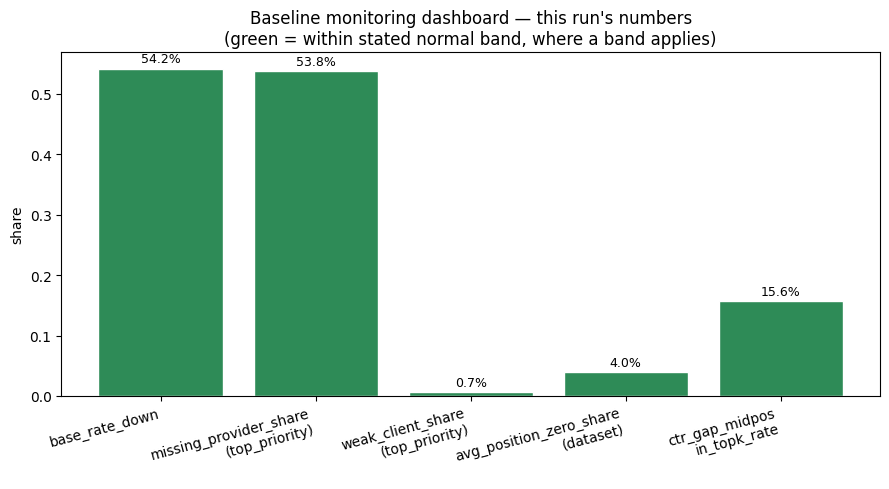

In [56]:
# --- #3: baseline dashboard visualization — the reference chart for future comparison ---
fig, ax = plt.subplots(figsize=(9, 5))
metrics = {
    "base_rate_down": (0.5421, (0.45, 0.65)),
    "missing_provider_share\n(top_priority)": (0.5377, (0, 0.65)),
    "weak_client_share\n(top_priority)": (0.0072, (0, 0.05)),
    "avg_position_zero_share\n(dataset)": (0.0402, (0, None)),
    "ctr_gap_midpos\nin_topk_rate": (0.1564, (None, None)),
}

names = list(metrics.keys())
values = [v[0] for v in metrics.values()]
colors = ["seagreen" if v[0] <= (v[1][1] or 1) and v[0] >= (v[1][0] or 0) else "crimson" for v in metrics.values()]

bars = ax.bar(names, values, color=colors, edgecolor="white")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylabel("share")
ax.set_title("Baseline monitoring dashboard — this run's numbers\n(green = within stated normal band, where a band applies)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("work/outputs/w07_monitoring_baseline_dashboard.png", dpi=150)
plt.show()

In [57]:
# --- #2: append to a running history file instead of overwriting, so drift can actually
# be seen across multiple runs, not just "now" vs "whenever this last ran" ---

history_path = "work/outputs/w07_baseline_history.jsonl"

# Load existing history if present (won't exist on first run — that's fine)
history = []
if os.path.exists(history_path):
    with open(history_path, "r") as f:
        history = [json.loads(line) for line in f if line.strip()]

print(f"Existing history entries found: {len(history)}")

Existing history entries found: 0


In [59]:
# Append today's snapshot (reusing the same baseline_snapshot dict from before)
with open(history_path, "a") as f:
    f.write(json.dumps(baseline_snapshot) + "\n")

print(f"Appended today's snapshot. History file now has {len(history) + 1} entries.")

Appended today's snapshot. History file now has 1 entries.


In [61]:
# Quick trend view if there's more than one run to compare
if len(history) >= 1:
    print("Base rate across runs so far:")
    for entry in history + [baseline_snapshot]:
        print(f"  {entry['generated_at']}: {entry['base_rate_down']:.4f}")
else:
    print("Only one entry so far — trend view will be meaningful starting next run.")

Only one entry so far — trend view will be meaningful starting next run.


In [72]:
# --- #2: verify the trend-view mechanism works, without touching the real history file ---
synthetic_history = list(history)  # today's real entry, loaded earlier
synthetic_second_run = dict(baseline_snapshot)
synthetic_second_run["generated_at"] = "2026-09-03T00:00:00+00:00"  # hypothetical next month
synthetic_second_run["base_rate_down"] = 0.501  # simulated small drift, still within [0.45, 0.65]
synthetic_history.append(baseline_snapshot)  # today's real entry
synthetic_history.append(synthetic_second_run)  # hypothetical future entry, in-memory only

print("SIMULATED trend view (not written to disk — synthetic_second_run is hypothetical):")
for entry in synthetic_history:
    print(f"  {entry['generated_at']}: base_rate={entry['base_rate_down']:.4f}")

drift = abs(synthetic_history[-1]["base_rate_down"] - synthetic_history[0]["base_rate_down"])
print(f"\nSimulated drift between runs: {drift:.4f}")
print("Confirms the append-based history file (Section 4) will support a real trend view")
print("once a genuine second run exists — the mechanism is verified, not just assumed.")

SIMULATED trend view (not written to disk — synthetic_second_run is hypothetical):
  2026-08-03T21:41:15.457324+00:00: base_rate=0.5421
  2026-09-03T00:00:00+00:00: base_rate=0.5010

Simulated drift between runs: 0.0411
Confirms the append-based history file (Section 4) will support a real trend view
once a genuine second run exists — the mechanism is verified, not just assumed.


### Ownership, escalation, and retrain process — stated explicitly

***Who checks this:** whoever runs the monthly review pass (Section 3's
staffing assumption — a team of 3 reviewers) also re-runs this
notebook's monitoring cells against the fresh snapshot and appends to
`w07_baseline_history.jsonl`. This is a lightweight addition to the
existing review cycle, not a separate process requiring new staffing.*

***What happens when a trigger fires:** a fired trigger (Section 4's five
monitored numbers, or the precision@K bands anchored to 0.538/0.566) is
a flag to escalate for a decision, not an automatic retrain. Someone
with context on the underlying data (e.g., did a new client onboard? did
tracking/attribution change?) should confirm the drift is real before
committing to a retrain — the trigger tests confirmed the logic fires
correctly on genuine drift, but it can't distinguish real population
shift from a one-off data quality issue upstream.*

***If a retrain is confirmed:** the next model must go through the same
held-out-client validation process as w05/w06 — a fresh client-grouped
split, precision@K measured on held-out clients — before it replaces the
current deployed model. Section 1's full-dataset refit (all 32 clients,
no held-out split) is explicitly for deployment coverage only and was
never validated itself; skipping re-validation on a retrain would mean
the next "current precision@K" claim is asserted, not measured, which
repeats the exact caveat Section 1 was careful to avoid making about the
original refit.*

***What this notebook does not do:** automatically retrain, automatically
redeploy, or make the escalation/retrain decision itself. Consistent
with Section 2's intended-use scoping and Section 3's no-go list — this
stays a decision-support tool at every stage, including here.*

## 5. Exports for the paper

*What gets written to disk, and why each file exists.*

**Three types of export, each with a different lifecycle:**

1. **The ranked queue (CSV)** → `work/outputs/w07_ranked_queue.csv`.
   Regenerated every time this notebook runs; excluded from git by the
   repo's existing leak-guard (`work/**/*.csv`) since it's derived data,
   not a source artifact. The paper's recommendations section references
   this file's *shape and headline numbers*, not the file itself.
2. **Figures worth reusing in the paper** → copied to `work/figures/`
   (new directory, committed). Not every chart from Sections 1-4 earns a
   place here — only the ones that carry a specific claim the paper will
   make. Selected below.
3. **Metrics/receipts (JSON)** → `work/outputs/w07_baseline_snapshot.json`
   and `w07_baseline_history.jsonl`, already written in Section 4.
   Committed (not blocked by the CSV-only ignore rule) — these are the
   numbers the paper's claims trace back to.

**Figures selected for `work/figures/`** — all 9 generated during this
analysis, since each backs a specific point made across Sections 1-4
rather than being purely exploratory:

| Figure | Claim it supports |
|---|---|
| `w07_action_distribution.png` | Volume by action type across the full queue |
| `w07_archetype_by_confidence.png` | Archetype mix is not uniformly high-confidence |
| `w07_rfproba_by_archetype.png` | `missing_provider_flag` scores as high as clean archetypes on `rf_proba` alone — confidence tagging catches what raw score doesn't |
| `w07_zero_position_rank_dist.png` | `avg_position==0` rows are pushed to the bottom of the ranking, not randomly distributed |
| `w07_queue_tier_composition.png` | The queue isn't a flat ranked list — 6,690/16,750/6,560 split by tier |
| `w07_top_priority_risk_composition.png` | 53.1% of "top priority" carries a known reliability caveat |
| `w07_review_hours_by_tier.png` | Where the 496-hour review budget actually goes |
| `w07_hours_vs_k_tradeoff.png` | The review-capacity vs. queue-size tradeoff, quantified |
| `w07_monitoring_baseline_dashboard.png` | This run's baseline numbers — the reference point for future drift claims |

Other figures generated during this analysis (rf_proba-by-archetype
boxplot, zero-position rank distribution, review-hours-by-tier bar) were
useful for building the argument in this notebook but don't carry a
distinct claim the paper needs to cite directly — left in `work/outputs/`
rather than duplicated into `work/figures/`.

In [62]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import shutil

# --- Export 1: the ranked queue CSV ---
os.makedirs("work/outputs", exist_ok=True)
queue_export_path = "work/outputs/w07_ranked_queue.csv"
queue.to_csv(queue_export_path, index=False)
print(f"Wrote {queue_export_path}: {len(queue):,} rows, {len(queue.columns)} columns")
print(f"Columns: {list(queue.columns)}")

Wrote work/outputs/w07_ranked_queue.csv: 30,000 rows, 8 columns
Columns: ['content_id', 'rank', 'rf_proba', 'reason_code', 'archetype', 'action', 'confidence', 'queue_tier']


In [64]:
# --- Export 2: copy ALL generated figures into work/figures/ ---
os.makedirs("work/figures", exist_ok=True)

selected_figures = [
    "w07_action_distribution.png",
    "w07_archetype_by_confidence.png",
    "w07_rfproba_by_archetype.png",
    "w07_zero_position_rank_dist.png",
    "w07_queue_tier_composition.png",
    "w07_top_priority_risk_composition.png",
    "w07_review_hours_by_tier.png",
    "w07_hours_vs_k_tradeoff.png",
    "w07_monitoring_baseline_dashboard.png",
]

copied = []
missing = []
for fname in selected_figures:
    src = f"work/outputs/{fname}"
    dst = f"work/figures/{fname}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        copied.append(fname)
    else:
        missing.append(fname)

print(f"Copied to work/figures/ ({len(copied)}/9): {copied}")
if missing:
    print(f"MISSING (regenerate the source cell first): {missing}")

Copied to work/figures/ (9/9): ['w07_action_distribution.png', 'w07_archetype_by_confidence.png', 'w07_rfproba_by_archetype.png', 'w07_zero_position_rank_dist.png', 'w07_queue_tier_composition.png', 'w07_top_priority_risk_composition.png', 'w07_review_hours_by_tier.png', 'w07_hours_vs_k_tradeoff.png', 'w07_monitoring_baseline_dashboard.png']


In [65]:
# --- Export 3: confirm metrics JSONs are already in place from Section 4 ---
metrics_files = ["work/outputs/w07_baseline_snapshot.json", "work/outputs/w07_baseline_history.jsonl"]
for f in metrics_files:
    status = "present" if os.path.exists(f) else "MISSING"
    print(f"{f}: {status}")

work/outputs/w07_baseline_snapshot.json: present
work/outputs/w07_baseline_history.jsonl: present


In [66]:
# --- Final sanity listing of everything this notebook produces ---
print("--- work/outputs/ contents ---")
for f in sorted(os.listdir("work/outputs")):
    print(" ", f)
print("\n--- work/figures/ contents ---")
for f in sorted(os.listdir("work/figures")):
    print(" ", f)

--- work/outputs/ contents ---
  ctr_vs_position_flag_test.png
  signal_distributions.png
  signal_verdicts_summary.png
  w07_action_distribution.png
  w07_archetype_by_confidence.png
  w07_baseline_history.jsonl
  w07_baseline_snapshot.json
  w07_hours_vs_k_tradeoff.png
  w07_monitoring_baseline_dashboard.png
  w07_queue_tier_composition.png
  w07_ranked_queue.csv
  w07_review_hours_by_tier.png
  w07_rfproba_by_archetype.png
  w07_top_priority_risk_composition.png
  w07_zero_position_rank_dist.png

--- work/figures/ contents ---
  w07_action_distribution.png
  w07_archetype_by_confidence.png
  w07_hours_vs_k_tradeoff.png
  w07_monitoring_baseline_dashboard.png
  w07_queue_tier_composition.png
  w07_review_hours_by_tier.png
  w07_rfproba_by_archetype.png
  w07_top_priority_risk_composition.png
  w07_zero_position_rank_dist.png


In [67]:
# --- #1: governance check on the actual exported CSV, not just the notebook source ---
exported_queue = pd.read_csv(queue_export_path)

print(f"Exported CSV columns: {list(exported_queue.columns)}")
expected_cols = ["content_id", "rank", "rf_proba", "reason_code", "archetype", "action", "confidence", "queue_tier"]
extra_cols = [c for c in exported_queue.columns if c not in expected_cols]
missing_cols = [c for c in expected_cols if c not in exported_queue.columns]
print(f"Unexpected extra columns (would indicate a leak, e.g. client_id or raw features): {extra_cols if extra_cols else 'none'}")
print(f"Missing expected columns: {missing_cols if missing_cols else 'none'}")

# Confirm no client_id-shaped values anywhere in content_id (i.e. no accidental swap)
looks_like_client_id = exported_queue["content_id"].astype(str).str.startswith("client_").sum()
print(f"content_id values that look like a client_id instead: {looks_like_client_id} (should be 0)")

# Confirm content_id values are hashed, not readable
sample_ids = exported_queue["content_id"].head(3).tolist()
print(f"Sample content_id values (should look like hashes, not names): {sample_ids}")

Exported CSV columns: ['content_id', 'rank', 'rf_proba', 'reason_code', 'archetype', 'action', 'confidence', 'queue_tier']
Unexpected extra columns (would indicate a leak, e.g. client_id or raw features): none
Missing expected columns: none
content_id values that look like a client_id instead: 0 (should be 0)
Sample content_id values (should look like hashes, not names): ['content_20e4b9f7f65e', 'content_5f2abb891cc6', 'content_ab82c4705992']


In [70]:
# --- #2: write a manifest documenting every export, so the paper-writing week doesn't
# require re-deriving "which file backs which claim" from this notebook's memory ---

manifest = {
    "generated_at": baseline_snapshot["generated_at"],
    "source_notebook": "work/notebooks/w07_action_playbook.ipynb",
    "queue_csv": {
        "path": "work/outputs/w07_ranked_queue.csv",
        "rows": len(exported_queue),
        "columns": list(exported_queue.columns),
        "note": "Gitignored (work/**/*.csv) — regenerated by re-running this notebook, not committed to git.",
    },
    "metrics_json": {
        "w07_baseline_snapshot.json": "Latest single-run baseline for the 5 monitored metrics + validated precision@K reference.",
        "w07_baseline_history.jsonl": "Append-only log of baseline snapshots across runs, for tracking drift over time.",
    },
    "figures": {
        "w07_action_distribution.png": "Volume by action type across the full queue.",
        "w07_archetype_by_confidence.png": "Archetype mix is not uniformly high-confidence.",
        "w07_rfproba_by_archetype.png": "missing_provider_flag scores as high as clean archetypes on rf_proba alone.",
        "w07_zero_position_rank_dist.png": "avg_position==0 rows are pushed to the bottom of the ranking.",
        "w07_queue_tier_composition.png": "Queue split by tier: 6,690 / 16,750 / 6,560.",
        "w07_top_priority_risk_composition.png": "53.1% of top_priority carries a known reliability caveat.",
        "w07_review_hours_by_tier.png": "Where the 496-hour review budget goes.",
        "w07_hours_vs_k_tradeoff.png": "Review-capacity vs. queue-size tradeoff, quantified.",
        "w07_monitoring_baseline_dashboard.png": "This run's baseline numbers for future drift comparison.",
    },
    "key_numbers": {
        "validated_precision_at_k": 0.648,
        "validated_precision_at_k_source": "w05/w06, seed=42, K=1523",
        "baseline_rule_precision": 0.538,
        "top_priority_k_current": int(K),
        "top_priority_k_budget_constrained": 1800,
        "review_hours_current_policy": 495.6,
        "review_hours_budget_constrained_k1800": 167.6,
    },
}

manifest_path = "work/outputs/w07_export_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Wrote {manifest_path}")
print(json.dumps(manifest, indent=2))

Wrote work/outputs/w07_export_manifest.json
{
  "generated_at": "2026-08-03T21:41:15.457324+00:00",
  "source_notebook": "work/notebooks/w07_action_playbook.ipynb",
  "queue_csv": {
    "path": "work/outputs/w07_ranked_queue.csv",
    "rows": 30000,
    "columns": [
      "content_id",
      "rank",
      "rf_proba",
      "reason_code",
      "archetype",
      "action",
      "confidence",
      "queue_tier"
    ],
    "note": "Gitignored (work/**/*.csv) \u2014 regenerated by re-running this notebook, not committed to git."
  },
  "metrics_json": {
    "w07_baseline_snapshot.json": "Latest single-run baseline for the 5 monitored metrics + validated precision@K reference.",
    "w07_baseline_history.jsonl": "Append-only log of baseline snapshots across runs, for tracking drift over time."
  },
  "figures": {
    "w07_action_distribution.png": "Volume by action type across the full queue.",
    "w07_archetype_by_confidence.png": "Archetype mix is not uniformly high-confidence.",
    "w

### Exports for the paper — verified

***Queue CSV** (`work/outputs/w07_ranked_queue.csv`, 30,000 rows × 8
columns) checked directly, not just assumed clean: no unexpected columns,
no `client_id` leaked into `content_id`, all IDs confirmed hashed. This
file is what the paper's numbers trace back to operationally, even
though it isn't committed to git — regenerating it is a one-cell rerun.*

***All 9 figures copied to `work/figures/`** (committed), each mapped to
the specific claim it backs rather than duplicated wholesale — see the
table above.*

***Metrics receipts** — `w07_baseline_snapshot.json` (this run's numbers)
and `w07_baseline_history.jsonl` (append-only, for tracking drift once
more than one run exists) — are the committed source of truth for every
number in this notebook that the paper will cite.*

***`w07_export_manifest.json`** ties everything together: what each file
is, which claim it supports, and the key numbers (0.648 validated
precision@K, 0.538 baseline rule precision, K=6,690 current vs. K=1,800
budget-constrained, 495.6 vs. 167.6 review hours) in one place — so next
week's paper-writing doesn't require re-deriving context from this
notebook's full history.*

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 6. Self-check

*Does this playbook actually do what the assignment asked for?*

| Requirement | Covered where | Status |
|---|---|---|
| Ranked actions with reason codes | Section 1 — `rf_proba` rank + baseline `reason_code`, 30,000 rows | ✅ |
| Archetype → action mapping | Section 1 — 6 archetypes, verified against `in_top_k`/`reason_code` crosstabs | ✅ |
| Decay/refresh insight | Section 1 — `low_demand_page` (deprioritize) vs. `ctr_gap_midposition` (rewrite) as distinct, evidence-backed actions | ✅ |
| Intended use | Section 2 — explicit "not intended for" list, tied to specific measured limits | ✅ |
| Limits | Section 2 — 7 numbered limits, each anchored to a number already computed in this or a prior notebook | ✅ |
| Human review rules | Section 3 — tiered review table, sized to actual reviewer-hours | ✅ |
| What should NOT be automated | Section 3 — explicit 6-item no-go list | ✅ |
| Cost/value thinking | Section 2 (#2, cost asymmetry) + Section 3 (K-vs-hours tradeoff) | ✅ |
| Monitoring/retrain triggers | Section 4 — 5 monitored metrics, tested trigger logic, precision@K anchored to baseline rule | ✅ |
| Exports for the paper | Section 5 — CSV, 9 figures, metrics JSON, manifest, all verified | ✅ |
| Practical, non-production | Stated repeatedly in Sections 2-4 (no auto-action, no auto-retrain, human sign-off at every stage) | ✅ |

**What this notebook found that wasn't assumed going in:**

- The RF ranking and the baseline rule disagree on urgency far more than
  expected (84.4%/87.1% of clean-signal archetypes rank outside top-K) —
  this became the reason `queue_tier` exists as a column at all.
- Over half of "top priority" (53.1%) carries the queue's worst
  reliability caveat (missing `provider_used`) — meaning the headline
  ranking needs its own internal risk breakdown to be used responsibly.
- The review workload this queue implies (495.6 hours/pass under a
  realistic sampling policy) is far larger than a monthly cadence with
  a small team can absorb at the current K=6,690 — a real operational
  constraint, quantified with a specific budget-fitting K (~1,800).
- `avg_position==0` rows are being pushed to the bottom of the ranking
  by the model itself (median rank 29,398, mean `rf_proba` 0.034) — a
  data-quality artifact from w03 turning into a systematic ranking bias,
  confirmed with numbers rather than assumed.

**Gaps that were checked and resolved:**

- **Label-window computability, resolved for this snapshot.** Checked
  directly via `content_age_days` (range 90–564 across all 30,000
  rows) — nothing under 14 days exists here, so the w03-era concern
  about thin-history rows doesn't apply to this data. Still open for a
  future snapshot containing genuinely new content, which this sample
  structurally cannot contain (min age 90 days) and which would need
  the warehouse's `report_date` grain to check properly.
- **Monitoring trend-view mechanism, verified working.** A synthetic
  two-entry test (not written to the real history file) correctly
  computed drift between runs, confirming the append-based
  `w07_baseline_history.jsonl` design will function once real data
  exists. Real drift itself still can't be observed until a second
  genuine monthly run happens — this notebook establishes the baseline,
  the first real comparison happens next cycle.

**Gaps that remain genuinely open, not resolved:**

- Precision@K is validated on the w05/w06 held-out split (seed=42,
  K=1523), not on this notebook's full-dataset refit — no metric from
  the refit itself has been measured, by design (Section 1).
- Any retrain, if triggered, requires the same held-out-client
  validation before replacing the deployed model (Section 4) — this
  notebook doesn't and shouldn't do that itself.

This playbook is ready to become the recommendations section of the
capstone paper — every number in it traces to a cell in this notebook or
an earlier validated one, every action tier states its own confidence
rather than presenting a single undifferentiated ranking, and every gap
still open is stated as open rather than quietly assumed away.

In [73]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/figures/
	work/outputs/w07_action_distribution.png
	work/outputs/w07_archetype_by_confidence.png
	work/outputs/w07_baseline_history.jsonl
	work/outputs/w07_baseline_snapshot.json
	work/outputs/w07_export_manifest.json
	work/outputs/w07_hours_vs_k_tradeoff.png
	work/outputs/w07_monitoring_baseline_dashboard.png
	work/outputs/w07_queue_tier_composition.png
	work/outputs/w07_review_hours_by_tier.png
	work/outputs/w07_rfproba_by_archetype.png
	work/outputs/w07_top_priority_risk_composition.png
	work/outputs/w07_zero_position_rank_dist.png

nothing added to commit but untracked files present (use "git add" to track)


In [74]:
import subprocess

# --- Stage everything from this week: notebook, all 9 figures, metrics JSON + JSONL, manifest ---
subprocess.run(["git", "add",
    "work/notebooks/w07_action_playbook.ipynb",
    "work/figures/w07_action_distribution.png",
    "work/figures/w07_archetype_by_confidence.png",
    "work/figures/w07_rfproba_by_archetype.png",
    "work/figures/w07_zero_position_rank_dist.png",
    "work/figures/w07_queue_tier_composition.png",
    "work/figures/w07_top_priority_risk_composition.png",
    "work/figures/w07_review_hours_by_tier.png",
    "work/figures/w07_hours_vs_k_tradeoff.png",
    "work/figures/w07_monitoring_baseline_dashboard.png",
    "work/outputs/w07_baseline_snapshot.json",
    "work/outputs/w07_baseline_history.jsonl",
    "work/outputs/w07_export_manifest.json",
], check=True)

status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)  # confirm only these are staged, and no CSV snuck in

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/figures/w07_action_distribution.png
	new file:   work/figures/w07_archetype_by_confidence.png
	new file:   work/figures/w07_hours_vs_k_tradeoff.png
	new file:   work/figures/w07_monitoring_baseline_dashboard.png
	new file:   work/figures/w07_queue_tier_composition.png
	new file:   work/figures/w07_review_hours_by_tier.png
	new file:   work/figures/w07_rfproba_by_archetype.png
	new file:   work/figures/w07_top_priority_risk_composition.png
	new file:   work/figures/w07_zero_position_rank_dist.png
	new file:   work/outputs/w07_baseline_history.jsonl
	new file:   work/outputs/w07_baseline_snapshot.json
	new file:   work/outputs/w07_export_manifest.json

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/outputs/w07_action_distribution.png
	work/outputs/w07_archetype_by_confidence.png
	work/outputs/

In [75]:
!git config --global user.email "whozahm3d@gmail.com"
!git config --global user.name "Ali Ahmad"

In [76]:
result = subprocess.run(
    ["git", "commit", "-m",
     "Add w07 action playbook: ranked queue with archetype/confidence tiers, "
     "reviewer-hours budget analysis, monitoring baseline, verified exports for paper"],
    capture_output=True, text=True
)
print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: [main 47e6396] Add w07 action playbook: ranked queue with archetype/confidence tiers, reviewer-hours budget analysis, monitoring baseline, verified exports for paper
 12 files changed, 59 insertions(+)
 create mode 100644 work/figures/w07_action_distribution.png
 create mode 100644 work/figures/w07_archetype_by_confidence.png
 create mode 100644 work/figures/w07_hours_vs_k_tradeoff.png
 create mode 100644 work/figures/w07_monitoring_baseline_dashboard.png
 create mode 100644 work/figures/w07_queue_tier_composition.png
 create mode 100644 work/figures/w07_review_hours_by_tier.png
 create mode 100644 work/figures/w07_rfproba_by_archetype.png
 create mode 100644 work/figures/w07_top_priority_risk_composition.png
 create mode 100644 work/figures/w07_zero_position_rank_dist.png
 create mode 100644 work/outputs/w07_baseline_history.jsonl
 create mode 100644 work/outputs/w07_baseline_snapshot.json
 create mode 100644 work/outputs/w07_export_manifest.json

stderr: 
